## 1. Load Dataset

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

path = kagglehub.dataset_download("shahzaibshazoo/mimo-radar-signal-dataset")

dataframes = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            try:
                df_temp = pd.read_csv(os.path.join(root, file))
                dataframes.append(df_temp)
            except:
                continue

df = pd.concat(dataframes, ignore_index=True)

print("Raw shape:", df.shape)

Using Colab cache for faster access to the 'mimo-radar-signal-dataset' dataset.
Raw shape: (1024000, 30)


In [2]:
df.head()

,angle,ant_1,ant_2,ant_3,ant_4,ant_5,ant_6,ant_7,ant_8,ant_9,...,ant_20,ant_21,ant_22,ant_23,ant_24,ant_25,ant_26,ant_27,ant_28,ant_29
0,[ 6 -60],-0.352069,-0.485423,0.116513,-0.233882,0.458108,0.379043,0.540715,0.605954,0.365611,...,-0.718812,-0.17989,-0.079381,-0.087451,0.49287,0.041632,0.853951,0.178179,0.810139,0.423609
1,[ 6 -60],0.170357,-0.57305,0.663978,-0.527521,0.595585,0.126971,0.179122,0.518687,-0.182372,...,-0.567772,0.172101,-0.033415,-0.142225,0.713558,-0.424302,0.949492,-0.102957,0.581019,0.226271
2,[ 6 -60],-0.456596,0.713491,-0.194506,0.302224,0.20152,-0.22622,0.599498,-0.631386,0.490064,...,0.040465,0.421526,-0.374632,0.664328,-0.49721,0.507626,-0.149997,0.01244,0.2912,-0.625858
3,[ 6 -60],0.644354,-0.115467,0.703978,-0.059561,0.290892,0.213591,-0.131864,0.226145,-0.616866,...,0.19235,0.305877,0.570045,-0.078068,0.70742,-0.215737,0.292881,-0.280895,-0.078254,-0.164049
4,[ 6 -60],0.287315,0.44181,0.056864,0.391904,-0.098312,0.20437,-0.227634,-0.395309,-0.162679,...,0.544199,0.237883,0.316646,0.297033,0.000481,0.097711,-0.292315,0.037675,-0.434165,-0.429267


## 2. Complex Signal Parsing

In [49]:
def parse_complex(val):
    try:
        return complex(val)
    except:
        return 0+0j

real_parts = []
imag_parts = []

antenna_cols = [col for col in df.columns if col.startswith("ant_")]

for col in antenna_cols:
    complex_vals = df[col].apply(parse_complex).values
    real_parts.append(np.real(complex_vals))
    imag_parts.append(np.imag(complex_vals))

X_real = np.column_stack(real_parts)
X_imag = np.column_stack(imag_parts)

magnitude = np.sqrt(X_real**2 + X_imag**2)

X = np.hstack((X_real, X_imag, magnitude))

X = X.astype(np.float32)

print(X.shape)

(1024000, 87)


## 3. Angle -> Beam Label Mapping

In [50]:
import re

def extract_angle(val):
    nums = re.findall(r'-?\d+', str(val))
    return int(nums[0]) if nums else 0

angles = df['angle'].apply(extract_angle)

NUM_BEAMS = 4

def angle_to_beam(angle):
    angle = (angle + 180) % 360
    return int(angle // (360 / NUM_BEAMS))

y = angles.apply(angle_to_beam).values

print(y.shape)

(1024000,)


## 4. Normalization + Train/Test Split

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

X = X / np.max(np.abs(X))

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# class_weights = {
#     0: 3.0,
#     1: 1.0,
#     2: 3.0,
#     3: 3.0,
#     4: 3.0,
#     5: 3.0,
#     6: 3.0,
#     7: 3.0
# }

# class_weights = dict(enumerate(weights))

class_weights = None
# print(class_weights)

y_train = to_categorical(y_train_raw, NUM_BEAMS)
y_test = to_categorical(y_test_raw, NUM_BEAMS)

print(X_train.shape, X_test.shape)

(819200, 87) (204800, 87)


## 5. CNN Model

### 5.1 Reshape for CNN

In [72]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)

(819200, 87, 1)


### 5.2 Build CNN Model

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),

    Conv1D(128, 3, activation='relu'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(NUM_BEAMS, activation='softmax')
])

optimizer = Adam(learning_rate=0.0005)

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        pt = tf.exp(-ce)
        return alpha * (1 - pt) ** gamma * ce
    return loss

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=focal_loss(),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 85, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 85, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 83, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 83, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 81, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,402,756 (5.35 MB)

 Trainable params: 1,402,372 (5.35 MB)

 Non-trainable params: 384 (1.50 KB)

## 6. Train Model

In [74]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.1,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/25
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.5062 - loss: 0.0451 - val_accuracy: 0.5140 - val_loss: 0.0433 - learning_rate: 5.0000e-04
Epoch 2/25
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.5085 - loss: 0.0434 - val_accuracy: 0.5050 - val_loss: 0.0433 - learning_rate: 5.0000e-04
Epoch 3/25
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.5094 - loss: 0.0433 - val_accuracy: 0.5151 - val_loss: 0.0433 - learning_rate: 5.0000e-04
Epoch 4/25
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.5171 - loss: 0.0432 - val_accuracy: 0.5287 - val_loss: 0.0431 - learning_rate: 2.5000e-04
Epoch 5/25
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.5254 - loss: 0.0432 - val_accuracy: 0.5294 - val_loss: 0.0431 - learning_rate: 2.5000e-04
Epoch 6/25
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.5320 - loss: 0.0431 - val_accuracy: 0.5327 - val_loss: 0.0430 - learning_rate: 2.5000e-04
Epoch 7/25
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 25s

## 7. Evaluate Model

In [75]:
loss, acc = model.evaluate(X_test, y_test)
print(acc)

6400/6400 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.5561 - loss: 0.0426
0.5560742020606995


## 8. Top-K Accuracy

In [76]:
import numpy as np

def top_k_accuracy(model, X, y_true, k=3):
    preds = model.predict(X)
    top_k = np.argsort(preds, axis=1)[:, -k:]
    y_true_labels = np.argmax(y_true, axis=1)
    return np.mean([y_true_labels[i] in top_k[i] for i in range(len(y_true_labels))])

print(top_k_accuracy(model, X_test, y_test, 3))

6400/6400 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1.0


## 9. Save Model

In [77]:
model.save("beam_selection_research.keras")

## 10.Accuracy Graph

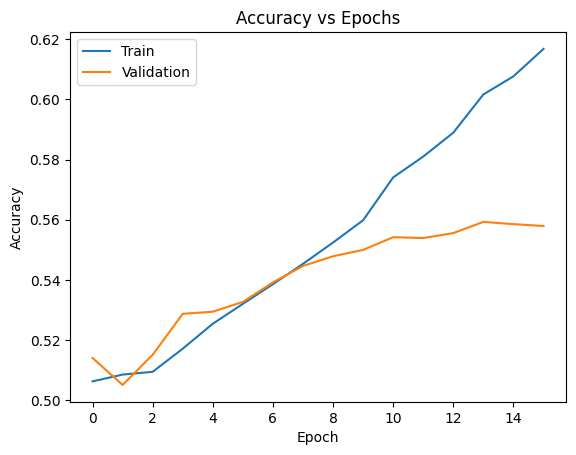

In [78]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## 11. Loss Graph

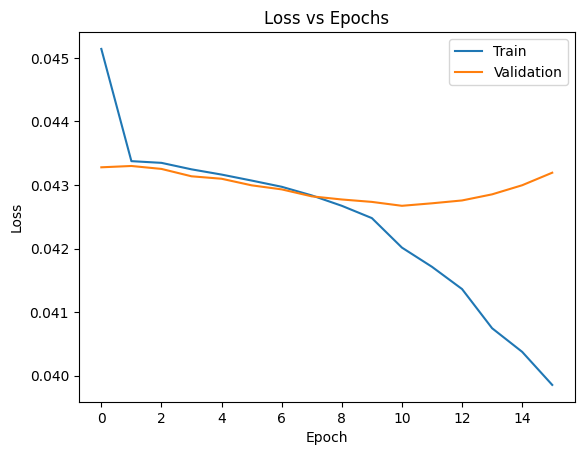

In [79]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 12. Confusion Matrix

6400/6400 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


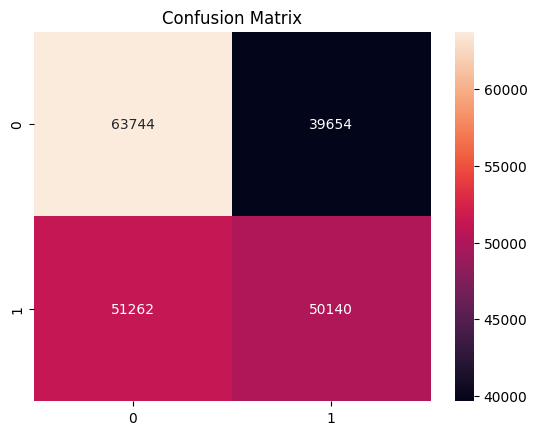

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## 13. Predict Function

In [61]:
def predict_beam(sample):
    sample = sample.reshape(1, -1)
    sample = scaler.transform(sample)
    sample = sample.reshape(1, sample.shape[1], 1)
    return np.argmax(model.predict(sample))

## 14. Top-K Generalized

In [62]:
def top_k_accuracy(model, X, y_true, k):
    preds = model.predict(X)
    top_k = np.argsort(preds, axis=1)[:, -k:]
    y_true_labels = np.argmax(y_true, axis=1)
    return np.mean([y_true_labels[i] in top_k[i] for i in range(len(y_true_labels))])

## 15. DFT Beamforming

In [63]:
def create_dft_codebook(N):
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-1j * 2 * np.pi * k * n / N) / np.sqrt(N)
    return W

antenna_cols = [col for col in df.columns if col.startswith("ant_")]

H = []

for i in range(len(df)):
    h = []
    for col in antenna_cols:
        try:
            h.append(complex(df[col].iloc[i]))
        except:
            h.append(0+0j)
    H.append(np.array(h))

H = np.array(H)

codebook = create_dft_codebook(len(antenna_cols))

gains = np.abs(np.matmul(H, codebook))**2

y_dft = np.argmax(gains, axis=1)

print(y_dft.shape)

(1024000,)


In [64]:
y = y_dft

## 16. Dense vs CNN Comparison

### 16.1 Dense Model

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

dense_model = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(NUM_BEAMS, activation='softmax')
])

dense_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

dense_model.fit(X_train.reshape(X_train.shape[0], -1), y_train, epochs=5, batch_size=128)

dense_acc = dense_model.evaluate(X_test.reshape(X_test.shape[0], -1), y_test)[1]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.5231 - loss: 0.6942
Epoch 2/5
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.5414 - loss: 0.6876
Epoch 3/5
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.5517 - loss: 0.6841
Epoch 4/5
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.5594 - loss: 0.6808
Epoch 5/5
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.5656 - loss: 0.6781
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.5537 - loss: 0.6834


### 16.2 CNN Model

In [66]:
cnn_acc = model.evaluate(X_test, y_test)[1]

6400/6400 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.5528 - loss: 0.8825


In [67]:
print("Dense Accuracy:", dense_acc)
print("CNN Accuracy:", cnn_acc)

Dense Accuracy: 0.5536572337150574
CNN Accuracy: 0.5527734160423279


## 17. Latency Analysis

In [68]:
import time

start = time.time()
_ = model.predict(X_test[:1000])
end = time.time()

latency = (end - start) / 1000

print("Avg Inference Time per Sample:", latency)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Avg Inference Time per Sample: 0.0005656709671020508


## 18. Ablation Study

In [69]:
# X_real_only = X_real
# Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_real_only, y, test_size=0.2)

# Xr_train = scaler.fit_transform(Xr_train)
# Xr_test = scaler.transform(Xr_test)

# Xr_train = Xr_train.reshape(Xr_train.shape[0], Xr_train.shape[1], 1)
# Xr_test = Xr_test.reshape(Xr_test.shape[0], Xr_test.shape[1], 1)

# model.fit(Xr_train, y_train, epochs=3)

# real_acc = model.evaluate(Xr_test, y_test)[1]

In [70]:
# X_imag_only = X_imag
# Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_imag_only, y, test_size=0.2)

# Xi_train = scaler.fit_transform(Xi_train)
# Xi_test = scaler.transform(Xi_test)

# Xi_train = Xi_train.reshape(Xi_train.shape[0], Xi_train.shape[1], 1)
# Xi_test = Xi_test.reshape(Xi_test.shape[0], Xi_test.shape[1], 1)

# model.fit(Xi_train, y_train, epochs=3)

# imag_acc = model.evaluate(Xi_test, y_test)[1]

In [71]:
# print("Real Only:", real_acc)
# print("Imag Only:", imag_acc)
# print("Real+Imag:", cnn_acc)